In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
text_emb_64 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_64.parquet'

RANDOM_STATE = 42

Project root: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits


# KNN based Model - on textual embeddings
By leveraging textual embeddings (128-dimensional vectors representing paper content), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with embedding

In [7]:
df = pd.read_parquet(text_emb_64)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.246657,0.013422,0.030803,-0.027900,0.031794,0.008041,...,0.005594,-0.024074,-0.018304,0.053269,-0.010537,0.015129,0.081555,-0.040338,0.035150,0.022799
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.180983,0.008709,-0.045347,0.040739,0.131509,-0.015846,...,-0.009488,0.010030,0.005332,-0.000430,0.039798,0.000698,0.001728,0.016241,0.015980,0.004910
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,0.077558,0.011321,-0.032596,-0.091188,0.033407,-0.025912,0.008252,0.035297,0.028148,0.000140
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,0.031245,0.020799,0.052592,0.052332,-0.035168,0.025643,0.025552,0.038130,0.078260,-0.080680
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,-0.064555,-0.034023,-0.025314,-0.018282,-0.022678,0.025053,0.034170,-0.035683,-0.019101,-0.014827


(2950135, 260)


In [8]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline Model

In [ ]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski', n_jobs=-1)
KNN_baseline = KNNModel()

KNN_baseline.train_pipeline(df_train)

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN] Starting training...


[KNN] Preprocessing data...
Label distribution:
is_reference_valid
0    0.5094
1    0.4906
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.6630    0.4121    0.5082      5094
           1     0.5618    0.7825    0.6540      4906

    accuracy                         0.5938     10000
   macro avg     0.6124    0.5973    0.5811     10000
weighted avg     0.6133    0.5938    0.5797     10000



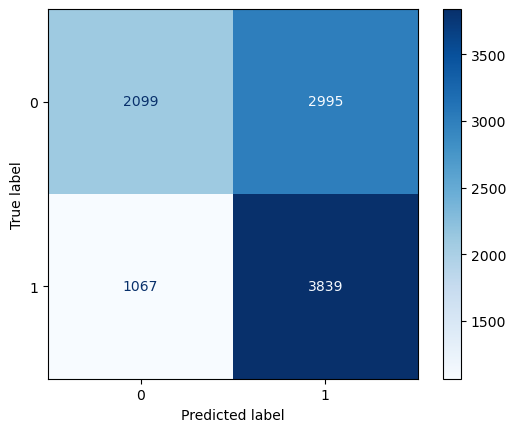

In [ ]:
KNN_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [ ]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [ ]:
# tuning
KNN_textual = KNNModel("KNN_textual_64")
KNN_textual.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=-1)

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
Starting tuning on 50000 samples...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [5, 9, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...ape=(50000,)))"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

In [ ]:
KNN_textual.test_pipeline(df_test)

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [ ]:
df_name = "knn_textual_embeddings_64"
model_family = "knn"
model_name = "knn_classifier"
split_name = "predefined_train_validation_test"
summary = {
        "scoring": "f1_weighted",
        "max_tuning_samples": int(max_tuning_samples),
        "train_subset_size": int(len(train_tuning_idx)),
        "val_subset_size": int(len(val_tuning_idx)),
    },

final_knn.save_model(params = best_params, df_name=df_name, model_family=model_family, split_name=split_name, summary=summary, force=False)